In [2]:
from datasets import load_dataset

ds = load_dataset("chainyo/rvl-cdip", cache_dir="./.hf_cache")

Resolving data files:   0%|          | 0/119 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/64 [00:00<?, ?it/s]

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import ResNet50_Weights
import numpy as np

torch.manual_seed(42)

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print(f"Using device: {device}")

Using device: mps


In [4]:
from PIL import UnidentifiedImageError

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class RVLCDIPDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        try:
            item = self.dataset[idx]
            image = item["image"]
            label = item["label"]
            if self.transform:
                image = self.transform(image)
            return image, label
        except (UnidentifiedImageError, OSError):
            # Skip corrupted images by returning the next valid one
            return self.__getitem__((idx + 1) % len(self))

train_dataset = RVLCDIPDataset(ds["train"], transform=transform)
val_dataset = RVLCDIPDataset(ds["val"], transform=transform)
test_dataset = RVLCDIPDataset(ds["test"], transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 319999, Val: 40000, Test: 40000


In [8]:
model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

# Freeze all backbone layers
for param in model.parameters():
    param.requires_grad = False

# Replace the final classification head for 16 classes
model.fc = nn.Linear(model.fc.in_features, 16)

model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 23,540,816
Trainable parameters: 32,784


In [ ]:
import os

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

num_epochs = 10
best_val_acc = 0.0
checkpoint_dir = "./checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

for epoch in range(num_epochs):
    # Training phase
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        if (batch_idx + 1) % 100 == 0:
            print(f"  Epoch {epoch+1}, Batch {batch_idx+1}/{len(train_loader)}, Loss: {loss.item():.4f}")

    train_loss = running_loss / total
    train_acc = correct / total

    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_loss /= val_total
    val_acc = val_correct / val_total

    scheduler.step()

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # Save checkpoint if validation accuracy improved
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_acc": val_acc,
            "val_loss": val_loss,
        }, os.path.join(checkpoint_dir, "best_model_resnet50_01.pt"))
        print(f"  -> Saved best model (val_acc: {val_acc:.4f})")

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

  Epoch 1, Batch 100/10000, Loss: 1.9540
  Epoch 1, Batch 200/10000, Loss: 1.7883
  Epoch 1, Batch 300/10000, Loss: 1.6095
  Epoch 1, Batch 400/10000, Loss: 1.6514
  Epoch 1, Batch 500/10000, Loss: 1.5621
  Epoch 1, Batch 600/10000, Loss: 1.3366
  Epoch 1, Batch 700/10000, Loss: 1.7793
  Epoch 1, Batch 800/10000, Loss: 1.4984
  Epoch 1, Batch 900/10000, Loss: 1.1810
  Epoch 1, Batch 1000/10000, Loss: 1.2022
  Epoch 1, Batch 1100/10000, Loss: 1.2288
  Epoch 1, Batch 1200/10000, Loss: 1.2535
  Epoch 1, Batch 1300/10000, Loss: 1.2888
  Epoch 1, Batch 1400/10000, Loss: 1.2180
  Epoch 1, Batch 1500/10000, Loss: 1.4606
  Epoch 1, Batch 1600/10000, Loss: 1.8056
  Epoch 1, Batch 1700/10000, Loss: 1.8904
  Epoch 1, Batch 1800/10000, Loss: 1.3623
  Epoch 1, Batch 1900/10000, Loss: 1.5763
  Epoch 1, Batch 2000/10000, Loss: 0.9604
  Epoch 1, Batch 2100/10000, Loss: 1.5218
  Epoch 1, Batch 2200/10000, Loss: 0.9896
  Epoch 1, Batch 2300/10000, Loss: 1.2469
  Epoch 1, Batch 2400/10000, Loss: 1.2841
 

Loaded best model from epoch 10 (val_acc: 0.6883)



/opt/homebrew/lib/python3.14/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Corrupt EXIF data.  Expecting to read 2 bytes but only got 0. 
  warnings.warn(str(msg))


Overall Test Accuracy: 0.6858

Class                     Accuracy
-----------------------------------
advertisement               0.8262
budget                      0.5649
email                       0.9213
file folder                 0.9256
form                        0.4649
handwritten                 0.8949
invoice                     0.6459
letter                      0.6071
memo                        0.5064
news article                0.7000
presentation                0.6119
questionnaire               0.5684
resume                      0.8088
scientific publication      0.8040
scientific report           0.3779
specification               0.7273


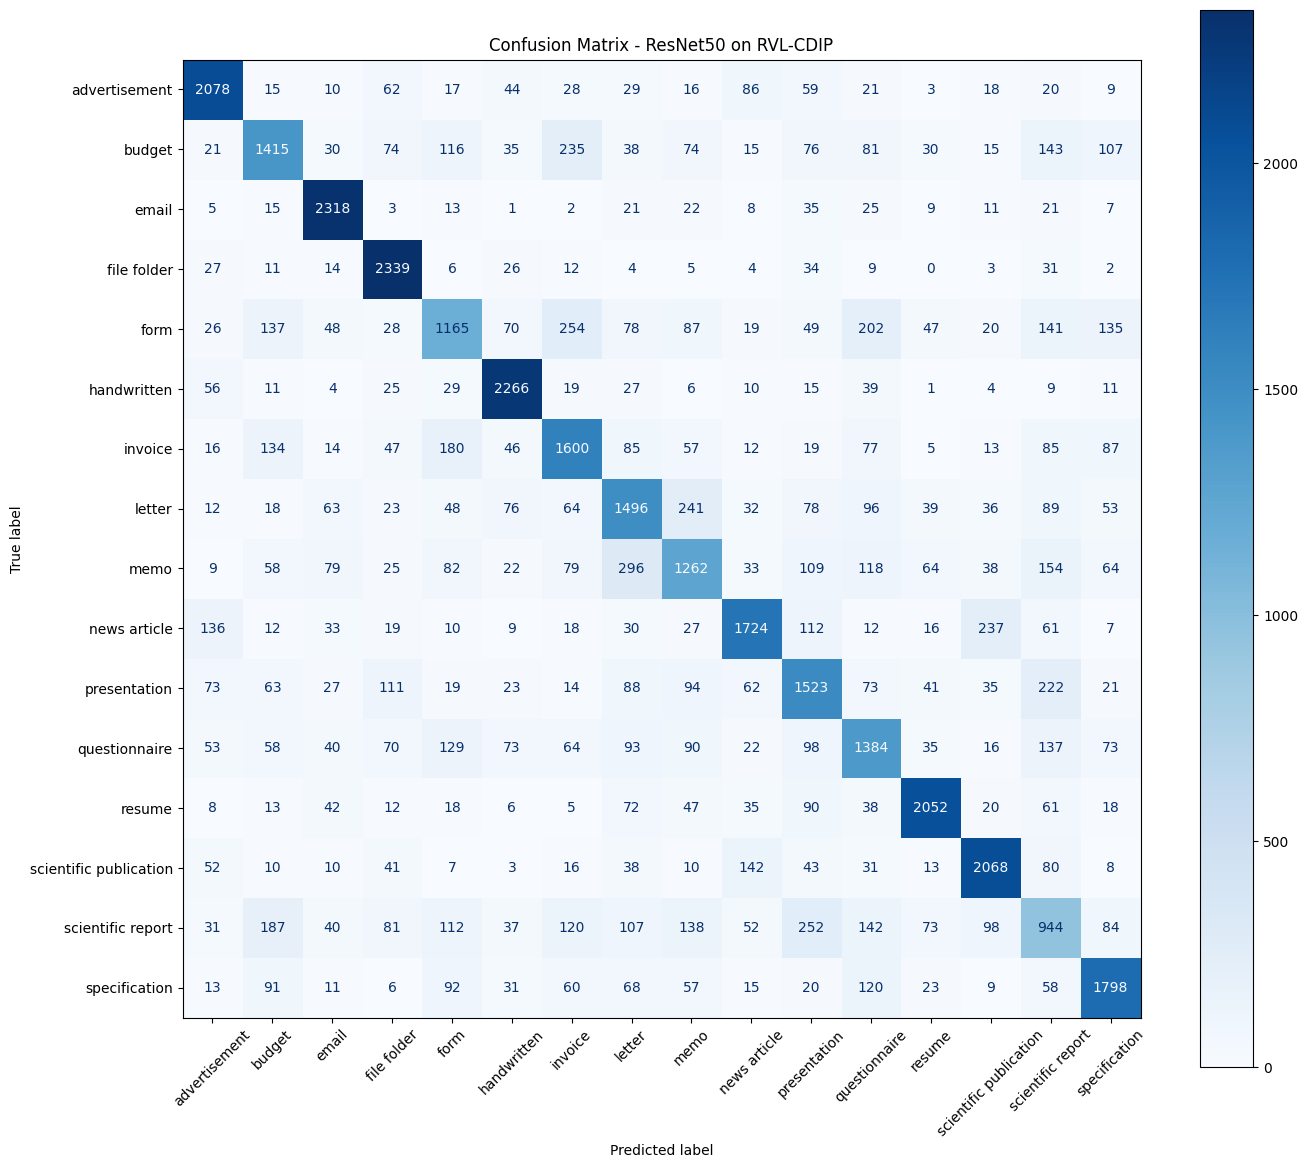

In [14]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load best checkpoint for evaluation
checkpoint_dir = "./checkpoints"
checkpoint = torch.load(os.path.join(checkpoint_dir, "best_model_resnet50_01.pt"), map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
print(f"Loaded best model from epoch {checkpoint['epoch']} (val_acc: {checkpoint['val_acc']:.4f})\n")

label_names = [
    "advertisement", "budget", "email", "file folder", "form",
    "handwritten", "invoice", "letter", "memo", "news article",
    "presentation", "questionnaire", "resume", "scientific publication",
    "scientific report", "specification",
]

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).sum() / len(all_labels)
print(f"Overall Test Accuracy: {test_acc:.4f}\n")

print(f"{'Class':<25} {'Accuracy':>8}")
print("-" * 35)
for i in range(16):
    mask = all_labels == i
    acc = (all_preds[mask] == all_labels[mask]).sum() / mask.sum() if mask.sum() > 0 else 0
    print(f"{label_names[i]:<25} {acc:>8.4f}")

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, values_format="d")
ax.set_title("Confusion Matrix - ResNet50 on RVL-CDIP")
plt.tight_layout()
plt.show()

In [15]:
# Stage 2: Unfreeze layer4 + FC fine-tuning
# Load best model from stage 1
checkpoint = torch.load(os.path.join(checkpoint_dir, "best_model_resnet50_01.pt"), map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
print(f"Loaded stage 1 checkpoint (val_acc: {checkpoint['val_acc']:.4f})")

# Freeze everything, then unfreeze layer4 and fc
for param in model.parameters():
    param.requires_grad = False
for param in model.layer4.parameters():
    param.requires_grad = True
for param in model.fc.parameters():
    param.requires_grad = True

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params:,}")

# Differential learning rates
optimizer = optim.Adam([
    {"params": model.layer4.parameters(), "lr": 1e-4},
    {"params": model.fc.parameters(), "lr": 1e-3},
])
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)
criterion = nn.CrossEntropyLoss()

num_epochs = 10
best_val_acc = 0.0

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        if (batch_idx + 1) % 100 == 0:
            print(f"  Epoch {epoch+1}, Batch {batch_idx+1}/{len(train_loader)}, Loss: {loss.item():.4f}")

    train_loss = running_loss / total
    train_acc = correct / total

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_loss /= val_total
    val_acc = val_correct / val_total

    scheduler.step()

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_acc": val_acc,
            "val_loss": val_loss,
        }, os.path.join(checkpoint_dir, "best_model_resnet50_02.pt"))
        print(f"  -> Saved best model (val_acc: {val_acc:.4f})")

print(f"\nBest validation accuracy (stage 2): {best_val_acc:.4f}")

Loaded stage 1 checkpoint (val_acc: 0.6883)
Trainable parameters: 14,997,520
  Epoch 1, Batch 100/10000, Loss: 1.3789
  Epoch 1, Batch 200/10000, Loss: 1.0582
  Epoch 1, Batch 300/10000, Loss: 1.2143
  Epoch 1, Batch 400/10000, Loss: 0.5565
  Epoch 1, Batch 500/10000, Loss: 0.9708
  Epoch 1, Batch 600/10000, Loss: 1.0171
  Epoch 1, Batch 700/10000, Loss: 0.9405
  Epoch 1, Batch 800/10000, Loss: 0.7732
  Epoch 1, Batch 900/10000, Loss: 0.9185
  Epoch 1, Batch 1000/10000, Loss: 1.0129
  Epoch 1, Batch 1100/10000, Loss: 0.8130
  Epoch 1, Batch 1200/10000, Loss: 0.8737
  Epoch 1, Batch 1300/10000, Loss: 1.0507
  Epoch 1, Batch 1400/10000, Loss: 0.6520
  Epoch 1, Batch 1500/10000, Loss: 0.8000
  Epoch 1, Batch 1600/10000, Loss: 1.0011
  Epoch 1, Batch 1700/10000, Loss: 0.8716
  Epoch 1, Batch 1800/10000, Loss: 0.6594
  Epoch 1, Batch 1900/10000, Loss: 0.5507
  Epoch 1, Batch 2000/10000, Loss: 0.8306
  Epoch 1, Batch 2100/10000, Loss: 1.0384
  Epoch 1, Batch 2200/10000, Loss: 0.5921
  Epoch 

In [16]:
# Stage 3: Unfreeze layer3 + layer4 + FC fine-tuning
# Load best model from stage 2
checkpoint = torch.load(os.path.join(checkpoint_dir, "best_model_resnet50_02.pt"), map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
print(f"Loaded stage 2 checkpoint (val_acc: {checkpoint['val_acc']:.4f})")

# Freeze everything, then unfreeze layer3, layer4, and fc
for param in model.parameters():
    param.requires_grad = False
for param in model.layer3.parameters():
    param.requires_grad = True
for param in model.layer4.parameters():
    param.requires_grad = True
for param in model.fc.parameters():
    param.requires_grad = True

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params:,}")

# Differential learning rates
optimizer = optim.Adam([
    {"params": model.layer3.parameters(), "lr": 1e-5},
    {"params": model.layer4.parameters(), "lr": 1e-4},
    {"params": model.fc.parameters(), "lr": 1e-3},
])
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)
criterion = nn.CrossEntropyLoss()

num_epochs = 10
best_val_acc = 0.0

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        if (batch_idx + 1) % 100 == 0:
            print(f"  Epoch {epoch+1}, Batch {batch_idx+1}/{len(train_loader)}, Loss: {loss.item():.4f}")

    train_loss = running_loss / total
    train_acc = correct / total

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_loss /= val_total
    val_acc = val_correct / val_total

    scheduler.step()

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_acc": val_acc,
            "val_loss": val_loss,
        }, os.path.join(checkpoint_dir, "best_model_resnet50_03.pt"))
        print(f"  -> Saved best model (val_acc: {val_acc:.4f})")

print(f"\nBest validation accuracy (stage 3): {best_val_acc:.4f}")

Loaded stage 2 checkpoint (val_acc: 0.8893)
Trainable parameters: 22,095,888
  Epoch 1, Batch 100/10000, Loss: 0.1114
  Epoch 1, Batch 200/10000, Loss: 0.1665
  Epoch 1, Batch 300/10000, Loss: 0.2855
  Epoch 1, Batch 400/10000, Loss: 0.0329
  Epoch 1, Batch 500/10000, Loss: 0.1937
  Epoch 1, Batch 600/10000, Loss: 0.0966
  Epoch 1, Batch 700/10000, Loss: 0.0494
  Epoch 1, Batch 800/10000, Loss: 0.0769
  Epoch 1, Batch 900/10000, Loss: 0.1207
  Epoch 1, Batch 1000/10000, Loss: 0.4413
  Epoch 1, Batch 1100/10000, Loss: 0.0692
  Epoch 1, Batch 1200/10000, Loss: 0.4428
  Epoch 1, Batch 1300/10000, Loss: 0.0166
  Epoch 1, Batch 1400/10000, Loss: 0.2499
  Epoch 1, Batch 1500/10000, Loss: 0.0137
  Epoch 1, Batch 1600/10000, Loss: 0.0145
  Epoch 1, Batch 1700/10000, Loss: 0.0755
  Epoch 1, Batch 1800/10000, Loss: 0.0913
  Epoch 1, Batch 1900/10000, Loss: 0.2213
  Epoch 1, Batch 2000/10000, Loss: 0.1947
  Epoch 1, Batch 2100/10000, Loss: 0.0764
  Epoch 1, Batch 2200/10000, Loss: 0.0248
  Epoch 

Loaded stage 3 checkpoint from epoch 9 (val_acc: 0.8951)



/opt/homebrew/lib/python3.14/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Corrupt EXIF data.  Expecting to read 2 bytes but only got 0. 
  warnings.warn(str(msg))


Overall Test Accuracy: 0.8947

Class                     Accuracy
-----------------------------------
advertisement               0.9197
budget                      0.8735
email                       0.9817
file folder                 0.9612
form                        0.8017
handwritten                 0.9514
invoice                     0.9031
letter                      0.8746
memo                        0.9121
news article                0.8961
presentation                0.8284
questionnaire               0.8489
resume                      0.9358
scientific publication      0.9180
scientific report           0.7882
specification               0.9159


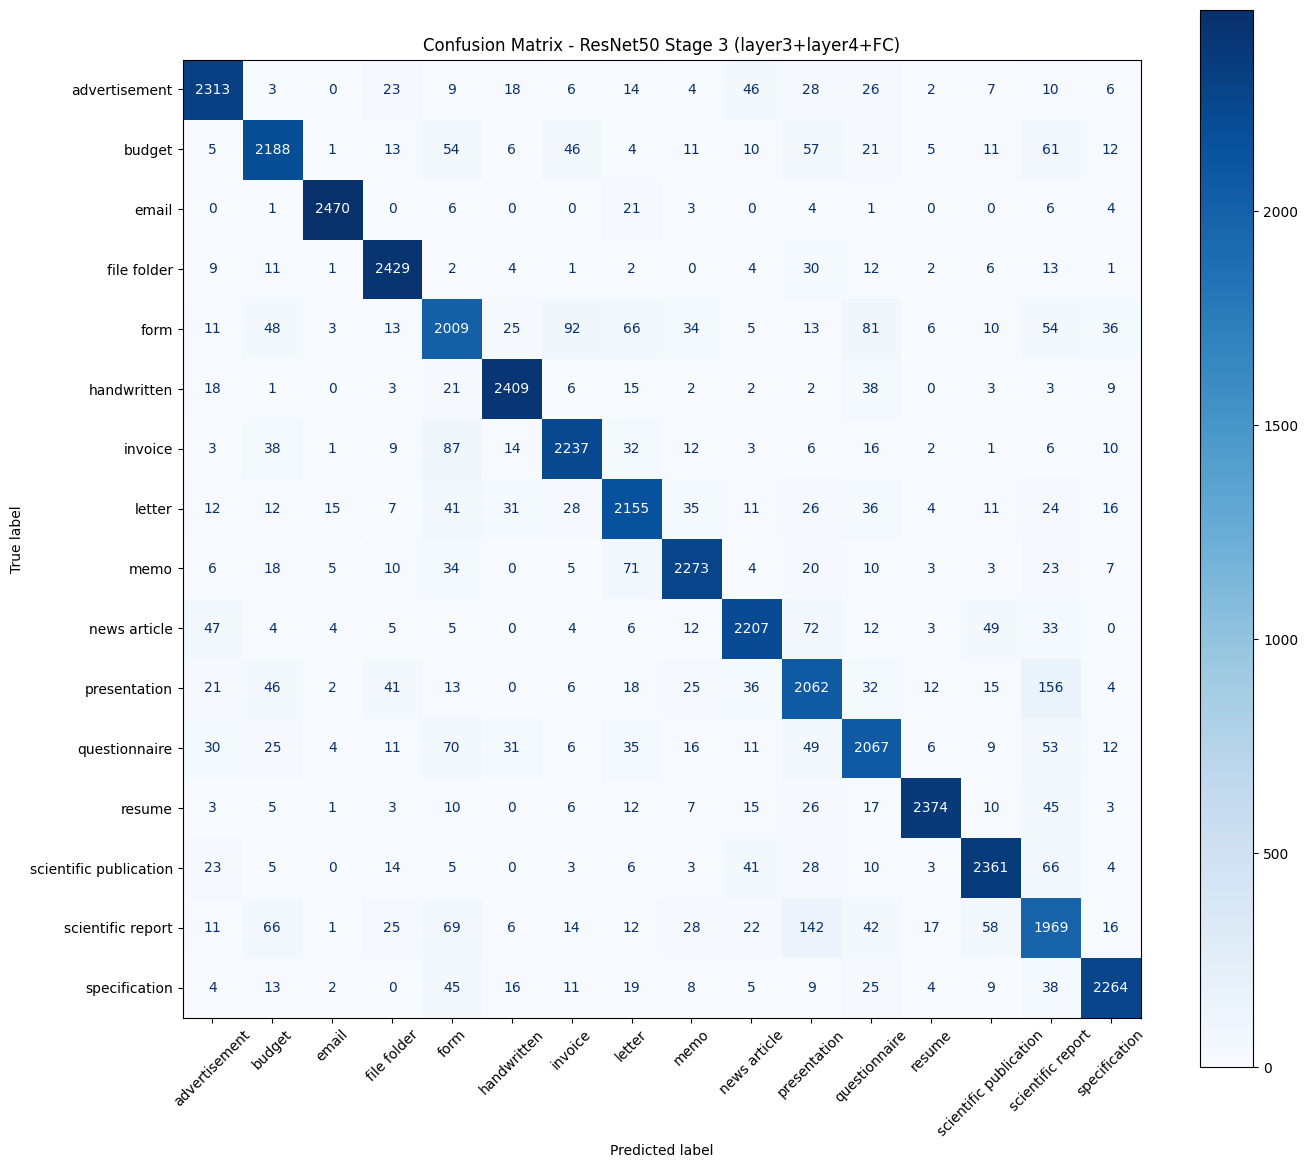

In [17]:
# Evaluation: Stage 3 (layer3 + layer4 + FC)
checkpoint = torch.load(os.path.join(checkpoint_dir, "best_model_resnet50_03.pt"), map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
print(f"Loaded stage 3 checkpoint from epoch {checkpoint['epoch']} (val_acc: {checkpoint['val_acc']:.4f})\n")

label_names = [
    "advertisement", "budget", "email", "file folder", "form",
    "handwritten", "invoice", "letter", "memo", "news article",
    "presentation", "questionnaire", "resume", "scientific publication",
    "scientific report", "specification",
]

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).sum() / len(all_labels)
print(f"Overall Test Accuracy: {test_acc:.4f}\n")

print(f"{'Class':<25} {'Accuracy':>8}")
print("-" * 35)
for i in range(16):
    mask = all_labels == i
    acc = (all_preds[mask] == all_labels[mask]).sum() / mask.sum() if mask.sum() > 0 else 0
    print(f"{label_names[i]:<25} {acc:>8.4f}")

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, values_format="d")
ax.set_title("Confusion Matrix - ResNet50 Stage 3 (layer3+layer4+FC)")
plt.tight_layout()
plt.show()